If you lack an adata file, then you can use the following command or visit [this website](https://data.mendeley.com/datasets/hhny5ff7yj/1) to download it.

```bash
mkdir data
wget -O ./data/ebdata_v3.h5ad https://data.mendeley.com/public-files/datasets/hhny5ff7yj/files/d82698f4-d143-442f-9a41-10be8ad02584/file_downloaded

In [1]:
%load_ext autoreload
%autoreload 2
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm.notebook import tqdm

from scFM_density_estimation.models import *
from scFM_density_estimation.utils import *

In [2]:
def sample_conditional_pt(x0, x1, t, sigma):
    mu_t = t * x1 + (1 - t) * x0
    epsilon = torch.randn_like(x0)
    return mu_t + sigma * epsilon

In [3]:
adata = sc.read_h5ad("./data/ebdata_v3.h5ad")
adata

AnnData object with n_obs × n_vars = 18203 × 17789
    obs: 'sample_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden', 'dpt_pseudotime', '1d-phate', '1d-phate-normalized'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'gene_name', 'gene_id', 'gene_name_id'
    uns: 'diffmap_evals', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'sample_labels_colors', 'tsne', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_phate', 'X_phate_normalized', 'X_phate_real_time', 'X_phate_time', 'X_tsne', 'X_umap'
    obsp: 'connectivities', 'distances'

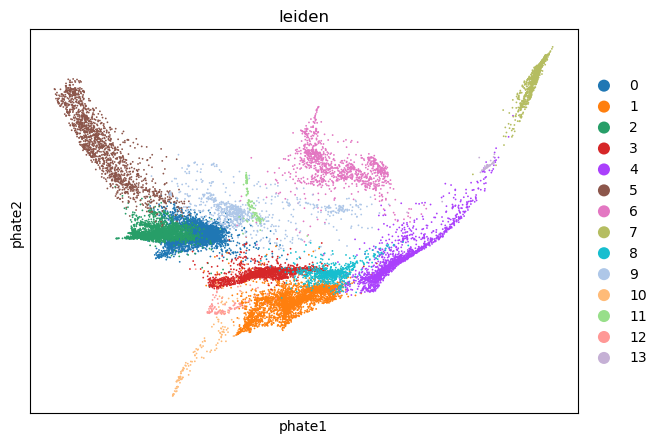

In [6]:
label = "leiden"
sc.pl.scatter(adata, basis="phate", color=label)

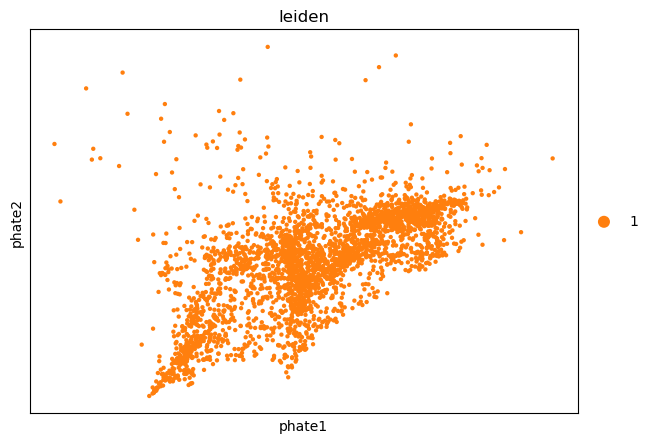

In [7]:
sc.pl.scatter(adata[adata.obs[label].cat.codes == 1], basis="phate", color=label)

In [8]:
adata.obsm["X_phate"]

array([[ 0.03160837,  0.00548253],
       [ 0.01777039, -0.0084755 ],
       [ 0.04239034,  0.03045232],
       ...,
       [-0.021551  , -0.00104214],
       [ 0.00247008, -0.01871763],
       [-0.01783222, -0.00182542]])

In [9]:
adata.X.toarray().shape

(18203, 17789)

In [10]:
label = "leiden" # sample_labels leiden
number = 1
n_categories = len(adata.obs[label].unique())

coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
X = adata.obsm["X_phate_standardized"][adata.obs[label].cat.codes == number]

  0%|          | 0/50000 [00:00<?, ?it/s]

10000: loss 0.336 time 16.84


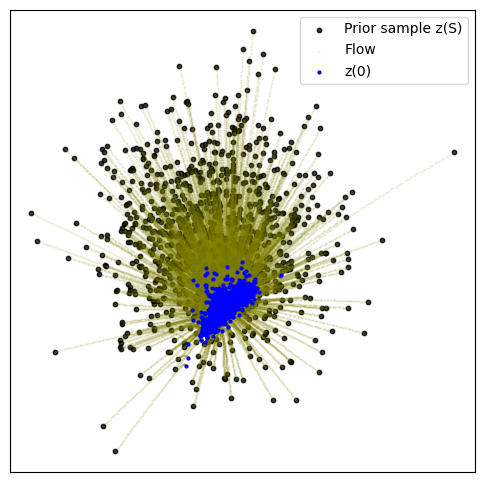

20000: loss 0.372 time 15.01


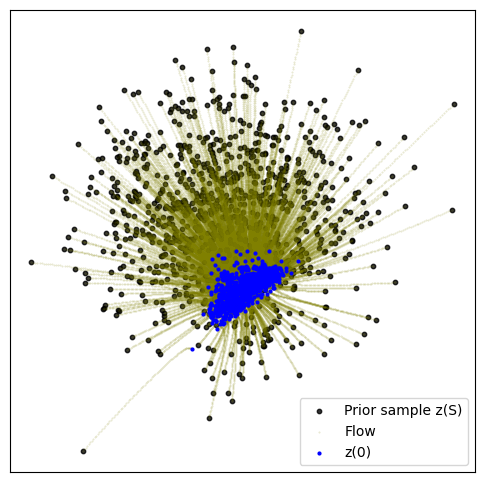

30000: loss 0.314 time 14.39


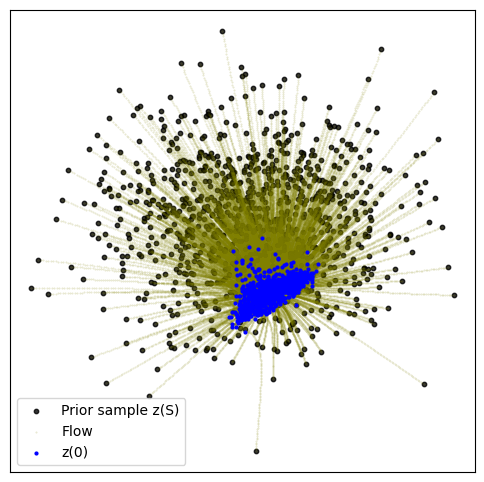

40000: loss 0.318 time 14.00


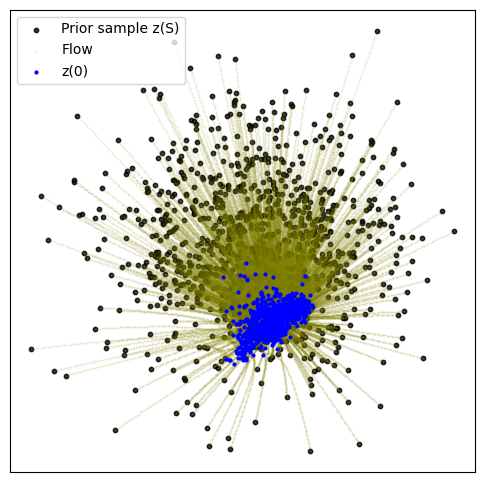

50000: loss 0.257 time 15.02


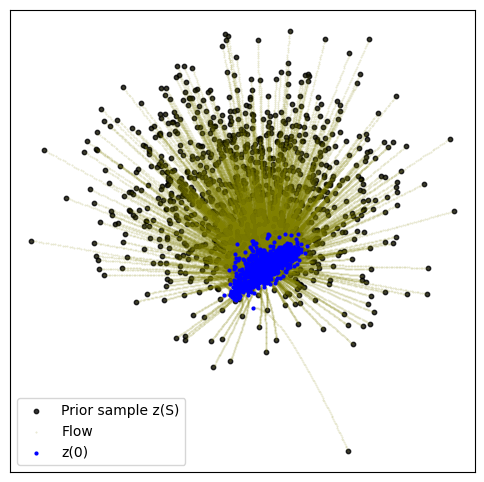

CPU times: user 1min 10s, sys: 1.52 s, total: 1min 11s
Wall time: 1min 16s


In [12]:
%%time
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
model = FlowMatchingMLP(input_dim=dim+1, hidden_dims=[64, 64, 64], output_dim=dim).to(device)
optimizer = torch.optim.Adam(model.parameters())
ot_sampler = OTPlanSampler(method="exact")

start = time.time()
for k in tqdm(range(50000)):
    optimizer.zero_grad()

    x1 = torch.from_numpy(X[np.random.randint(X.shape[0], size=batch_size)]).float().to(device)
    x0 = torch.randn_like(x1).to(device)

    #x0, x1 = ot_sampler.sample_plan(x0, x1)

    t = torch.rand(x1.shape[0]).type_as(x1).unsqueeze(1).to(device)
    #xt = x0 + t * (x1 - x0)
    xt = sample_conditional_pt(x0, x1, t, sigma=0.01).to(device)
    ut = x1 - x0
    
    vt = model(xt, t)
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 10000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                torch.randn_like(x1.repeat(4, 1)).to(device),
                t_span=torch.linspace(0, 1, 100).to(device),
            )
            plot_trajectories(traj.cpu().numpy())

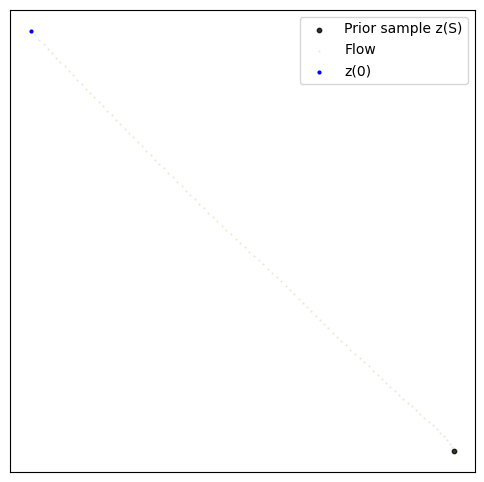

In [13]:
node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(np.array([[0.25, -1.1]])).type_as(x1).to(device),
        t_span=torch.linspace(1, 0, 100).to(device),
    )
    plot_trajectories(traj.cpu().numpy())

In [14]:
z0 = traj[-1]
log_p0 = -0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi)
print(log_p0)

tensor([-1.8713], device='cuda:0')


In [15]:
z0

tensor([[-0.2101,  0.1504]], device='cuda:0')

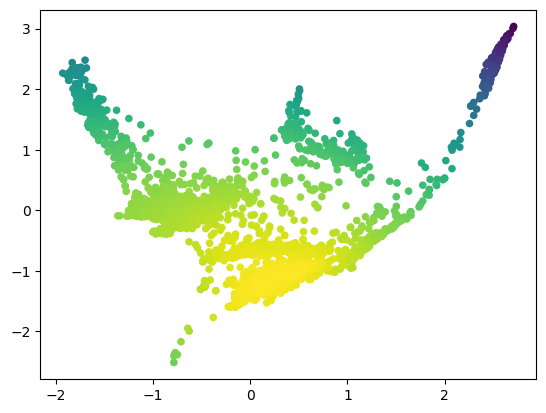

In [16]:
data = adata.obsm["X_phate_standardized"]
data = data[np.random.randint(data.shape[0], size=3000)]

node = NeuralODE(
    torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
)
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(data).type_as(x1).to(device),
        t_span=torch.linspace(1, 0, 200).to(device),
    )

z0 = traj[-1]
log_p0 = -0.5 * (z0 ** 2).sum(dim=1) - 0.5 * z0.shape[1] * np.log(2 * np.pi)

plt.scatter(x=data[:, 0], y=data[:, 1], c=log_p0.cpu().numpy(), s=20, cmap='viridis')

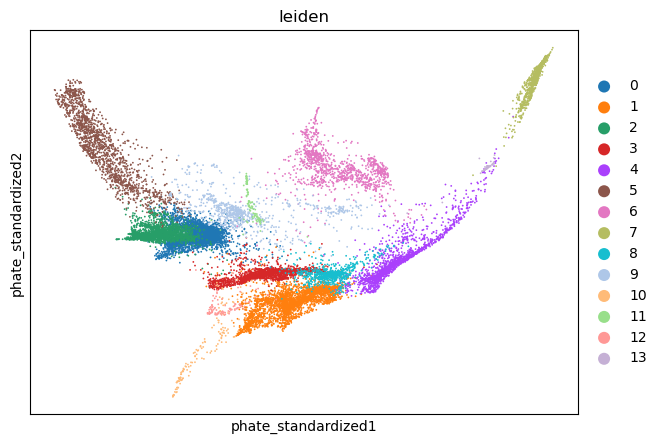

In [17]:
label = "leiden"
sc.pl.scatter(adata, basis="phate_standardized", color=label)